# 06_01 Feature batch: store-day temperature anomaly

First feature batch of the `06_` series, and the first one motivated by an external data
source rather than by the demand history itself.

## What changed

**One column**, `temperature_anomaly_c`, added to `builder.py`:

```text
temperature_anomaly_c = temperature(store, forecast day)
                      - seasonal normal(store, that calendar day)
```

The seasonal normal is the mean temperature over dates within ±7 calendar days of the
target day-of-year, taken **strictly before the origin**, and requires at least ten such
dates or the feature is null. Stores are assigned to the nearest 0.25° ERA5 grid cell.
`FEATURE_BUILDER_VERSION` was bumped `2026-08-07.1` → `.2`, all 72 partitions were rebuilt,
and only the two-stage model was refit. Stage routing is exclusion-based, so the column
reaches **both** the occurrence and the positive-quantity booster.

## Mechanism and expected effect, stated before running

**Mechanism.** Warm days shift demand between articles — grilling cuts up, roasts and stews
down. The model already carries the *seasonal* temperature path through `month`, `iso_week`,
and its trailing means, but it has never observed whether a given day is warmer or colder
*than normal for its time of year*. `01_05` showed the response is article-specific
(I² = 85.6%, relative effect spanning roughly −37% to +83% per +10 °C), which is why a
pooled sourcing-group slope reported approximately nothing.

**Expected effect,** quantified in `05_10` by applying a per-article correction to these
same frozen forecasts: **row ≈ −0.69 pp, article-store-week ≈ −0.78 pp, article-day ≈
−1.32 pp, with bias moving slightly toward zero.** That estimate is a bound on the
*available signal* under a crude linear multiplicative correction. A refit can beat it, by
conditioning the response on promotions, events, and recent demand, or miss it, by
overfitting the interaction.

**Falsifiable prediction.** The gain should concentrate on origins whose weather departed
most from seasonal normal — above all 2026-05-11 (−6.3 °C) and 2026-06-22 (+5.4 °C). A gain
spread evenly across origins would mean the metric moved for some other reason.

Baseline for the comparison is the `05_08` run, backed up in
`reports/results/backup_pre_weather/`.

In [1]:
import os
from pathlib import Path

os.environ.setdefault("OMP_NUM_THREADS", "1")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

PROJECT_ROOT = next(
    (p.resolve() for p in [Path("../.."), Path(".")] if (p / "data").exists()), None
)
RESULTS = PROJECT_ROOT / "reports/results"
NEW_FORECASTS = RESULTS / "forecasts/artikel_markt_multi7days_lightgbm_two_stage.csv"
OLD_FORECASTS = RESULTS / "backup_pre_weather/forecasts_two_stage.csv"
NEW_IMPORTANCE = RESULTS / "feature_importance/artikel_markt_multi7days_lightgbm_two_stage.csv"
OLD_IMPORTANCE = RESULTS / "backup_pre_weather/feature_importance_two_stage.csv"
FEATURE_STORE = PROJECT_ROOT / "data/processed/model_features/lightgbm_daily/v1"

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 120, "savefig.bbox": "tight"})

FORECAST_COLUMNS = [
    "ARTIKEL_ID", "MARKT_ID", "sourcing_group", "origin", "period",
    "actual", "forecast", "is_active", "recent_occurrence_rate",
]

def load_forecasts(path, columns=FORECAST_COLUMNS):
    chunks = []
    for chunk in pd.read_csv(path, usecols=columns, chunksize=2_000_000):
        chunks.append(chunk[chunk.is_active == True].drop(columns="is_active"))
    frame = pd.concat(chunks, ignore_index=True).dropna(subset=["actual", "forecast"])
    frame["origin"] = pd.to_datetime(frame.origin)
    frame["period"] = pd.to_datetime(frame.period)
    return frame

new_forecasts = load_forecasts(NEW_FORECASTS)
old_forecasts = load_forecasts(OLD_FORECASTS)

keys = ["ARTIKEL_ID", "MARKT_ID", "origin", "period"]
comparison = new_forecasts.merge(
    old_forecasts[keys + ["forecast"]].rename(columns={"forecast": "forecast_old"}),
    on=keys, how="inner", validate="one_to_one",
)
if len(comparison) != len(new_forecasts) or len(comparison) != len(old_forecasts):
    raise ValueError("The two runs do not cover an identical row set.")

display(pd.DataFrame([{
    "rows compared": len(comparison),
    "origins": comparison.origin.nunique(),
    "series": comparison.groupby(["ARTIKEL_ID", "MARKT_ID"]).ngroups,
}]).style.hide(axis="index"))

rows compared,origins,series
2502829,20,21904


## Verification: does the feature exist, and does it behave?

Before attributing any metric change to temperature, confirm the column was actually
materialised with sensible values — non-trivial coverage, a roughly centred distribution,
and no drift across origins that would signal a lagging baseline.

,Value
generation,92553ff0738e05a06d80
partitions,72
materialised rows,10106012
non-null share,100.0%
mean (°C),-0.393048
SD (°C),3.348097
min / max (°C),-12.4 / 10.7


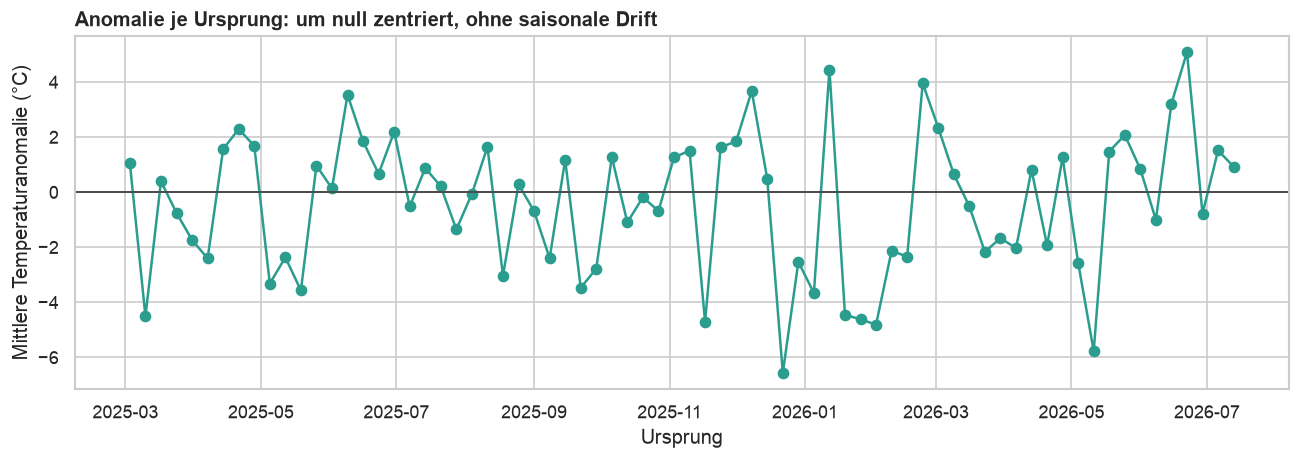

In [2]:
generations = sorted(FEATURE_STORE.glob("*")) if FEATURE_STORE.exists() else []
if not generations:
    raise FileNotFoundError(f"No feature-store generation under {FEATURE_STORE}")
generation = max(generations, key=lambda path: path.stat().st_mtime)
partitions = sorted(generation.glob("origin=*/*.parquet")) or sorted(generation.glob("*.parquet"))

anomaly_rows = []
for partition in partitions:
    frame = pd.read_parquet(partition, columns=["origin", "period", "temperature_anomaly_c"])
    anomaly_rows.append(frame)
anomalies = pd.concat(anomaly_rows, ignore_index=True)
anomalies["origin"] = pd.to_datetime(anomalies.origin)

display(pd.DataFrame([{
    "generation": generation.name,
    "partitions": len(partitions),
    "materialised rows": len(anomalies),
    "non-null share": f"{anomalies.temperature_anomaly_c.notna().mean():.1%}",
    "mean (°C)": anomalies.temperature_anomaly_c.mean(),
    "SD (°C)": anomalies.temperature_anomaly_c.std(),
    "min / max (°C)": (
        f"{anomalies.temperature_anomaly_c.min():.1f} / "
        f"{anomalies.temperature_anomaly_c.max():.1f}"
    ),
}]).T.rename(columns={0: "Value"}))

by_origin = (
    anomalies.groupby("origin", as_index=False)
    .temperature_anomaly_c.mean()
    .rename(columns={"temperature_anomaly_c": "mean_anomaly_c"})
)
figure, axis = plt.subplots(figsize=(11, 4))
axis.plot(by_origin.origin, by_origin.mean_anomaly_c, marker="o", color="#2A9D8F")
axis.axhline(0, color="0.3", linewidth=1.2)
axis.set_xlabel("Ursprung")
axis.set_ylabel("Mittlere Temperaturanomalie (°C)")
axis.set_title(
    "Anomalie je Ursprung: um null zentriert, ohne saisonale Drift",
    loc="left", weight="bold",
)
figure.tight_layout()
plt.show()

## Target metrics: WAPE at three grains plus relative bias

The batch scoreboard. Bias near zero is a standing requirement, so a WAPE gain bought with
bias is not a gain.

In [3]:
def grain_metrics(frame, column):
    weekly = frame.groupby(["ARTIKEL_ID", "MARKT_ID", "origin"], observed=True).agg(
        actual=("actual", "sum"), forecast=(column, "sum")
    )
    article_day = frame.groupby(["ARTIKEL_ID", "period"], observed=True).agg(
        actual=("actual", "sum"), forecast=(column, "sum")
    )
    return {
        "row (article-store-day)": (
            (frame[column] - frame.actual).abs().sum() / frame.actual.sum() * 100
        ),
        "article-store-week": (
            (weekly.forecast - weekly.actual).abs().sum() / weekly.actual.sum() * 100
        ),
        "article-day": (
            (article_day.forecast - article_day.actual).abs().sum()
            / article_day.actual.sum() * 100
        ),
        "relative bias": (
            (frame[column].sum() - frame.actual.sum()) / frame.actual.sum() * 100
        ),
    }

grain_table = pd.DataFrame({
    "Before (05_08)": grain_metrics(comparison, "forecast_old"),
    "After (+ temperature)": grain_metrics(comparison, "forecast"),
})
grain_table["Delta"] = grain_table["After (+ temperature)"] - grain_table["Before (05_08)"]
grain_table["05_10 predicted"] = [-0.691, -0.784, -1.316, +0.191]
display(grain_table.style.format("{:.3f}", subset=grain_table.columns[:2]).format(
    "{:+.3f}", subset=["Delta", "05_10 predicted"]
))

,Before (05_08),After (+ temperature),Delta,05_10 predicted
row (article-store-day),58.178,58.063,-0.115,-0.691
article-store-week,37.743,37.681,-0.062,-0.784
article-day,25.130,24.917,-0.213,-1.316
relative bias,-0.886,-0.915,-0.029,+0.191


## Did the gain follow the predicted mechanism?

The stated prediction was that the improvement concentrates on origins whose weather
departed most from seasonal normal, not uniformly.

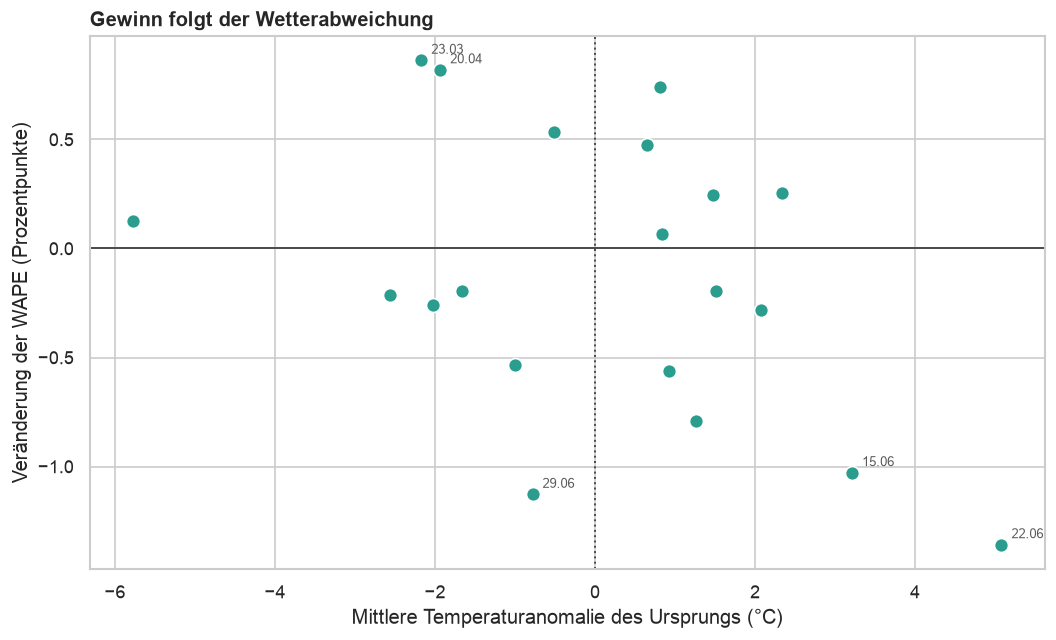

origin,mean_anomaly_c,before,after,delta
2026-03-02,+2.34,55.82,56.07,+0.25
2026-03-09,+0.65,59.82,60.30,+0.47
2026-03-16,-0.51,57.43,57.96,+0.54
2026-03-23,-2.17,61.17,62.03,+0.86
2026-03-30,-1.67,49.71,49.51,-0.19
2026-04-06,-2.03,58.83,58.57,-0.26
2026-04-13,+0.81,67.52,68.26,+0.74
2026-04-20,-1.94,57.57,58.39,+0.82
2026-04-27,+1.26,55.99,55.19,-0.79
2026-05-04,-2.56,56.48,56.27,-0.21


**11 of 20 origins improved.** Correlation between the absolute origin anomaly and the WAPE change: -0.25 (negative = the more unusual the weather, the larger the gain).

In [4]:
origin_rows = []
for origin, frame in comparison.groupby("origin"):
    origin_rows.append({
        "origin": origin,
        "mean_anomaly_c": by_origin.loc[
            by_origin.origin == origin, "mean_anomaly_c"
        ].mean(),
        "before": (frame.forecast_old - frame.actual).abs().sum() / frame.actual.sum() * 100,
        "after": (frame.forecast - frame.actual).abs().sum() / frame.actual.sum() * 100,
    })
origin_table = pd.DataFrame(origin_rows)
origin_table["delta"] = origin_table.after - origin_table.before
improved = int((origin_table.delta < 0).sum())
mechanism_correlation = origin_table.mean_anomaly_c.abs().corr(origin_table.delta)

figure, axis = plt.subplots(figsize=(9, 5.5))
axis.scatter(
    origin_table.mean_anomaly_c, origin_table.delta,
    s=70, color="#2A9D8F", edgecolor="white", zorder=3,
)
axis.axhline(0, color="0.3", linewidth=1.2)
axis.axvline(0, color="0.3", linewidth=1.2, linestyle=":")
for row in origin_table.itertuples(index=False):
    if abs(row.delta) > 0.8:
        axis.annotate(
            f"{row.origin:%d.%m}", (row.mean_anomaly_c, row.delta),
            textcoords="offset points", xytext=(6, 4), fontsize=8, color="0.35",
        )
axis.set_xlabel("Mittlere Temperaturanomalie des Ursprungs (°C)")
axis.set_ylabel("Veränderung der WAPE (Prozentpunkte)")
axis.set_title(
    "Gewinn folgt der Wetterabweichung", loc="left", weight="bold",
)
figure.tight_layout()
plt.show()

display(origin_table.assign(origin=lambda f: f.origin.dt.date).style.hide(axis="index").format({
    "mean_anomaly_c": "{:+.2f}", "before": "{:.2f}", "after": "{:.2f}", "delta": "{:+.2f}",
}))
display(Markdown(
    f"**{improved} of {len(origin_table)} origins improved.** Correlation between the "
    f"absolute origin anomaly and the WAPE change: {mechanism_correlation:+.2f} "
    "(negative = the more unusual the weather, the larger the gain)."
))

## Did the boosters actually use the feature?

Gain share is normalised within each stage and refit block, so the numbers are comparable
across runs.

In [5]:
new_importance = pd.read_csv(NEW_IMPORTANCE)
old_importance = pd.read_csv(OLD_IMPORTANCE)

def rank_table(frame, label):
    frame = frame.copy()
    frame["rank"] = frame.groupby(["evaluation_origin", "stage"]).gain_share.rank(
        ascending=False, method="min"
    )
    summary = (
        frame.groupby(["stage", "feature"], as_index=False)
        .agg(mean_gain_share=("gain_share", "mean"), mean_rank=("rank", "mean"))
    )
    summary["run"] = label
    return summary

importance = pd.concat([
    rank_table(old_importance, "Before"), rank_table(new_importance, "After"),
], ignore_index=True)

temperature_importance = importance[importance.feature == "temperature_anomaly_c"]
display(temperature_importance.style.hide(axis="index").format({
    "mean_gain_share": "{:.4%}", "mean_rank": "{:.1f}",
}))

features_per_stage = new_importance.groupby("stage").feature.nunique()
display(Markdown(
    "*Mean gain share and mean rank across the five expanding refit blocks, out of "
    + " / ".join(f"{count} features in the {stage} stage" for stage, count in features_per_stage.items())
    + ".*"
))

top_movers = (
    importance.pivot_table(
        index=["stage", "feature"], columns="run", values="mean_gain_share"
    )
    .dropna()
    .assign(change=lambda f: f["After"] - f["Before"])
    .sort_values("change")
)
display(Markdown("**Largest gain-share shifts** (which features the new column displaced):"))
display(pd.concat([top_movers.head(6), top_movers.tail(6)]).style.format("{:.4%}"))

stage,feature,mean_gain_share,mean_rank,run
occurrence,temperature_anomaly_c,0.0296%,34.6,After
positive_quantity,temperature_anomaly_c,0.1966%,26.0,After


*Mean gain share and mean rank across the five expanding refit blocks, out of 51 features in the occurrence stage / 51 features in the positive_quantity stage.*

**Largest gain-share shifts** (which features the new column displaced):

## Guardrail: portfolio segments and intermittency bands

A batch that improves the aggregate while damaging a segment is not acceptable.

In [6]:
comparison["band"] = pd.cut(
    comparison.recent_occurrence_rate, [-0.01, 0.3, 0.9, 1.01],
    labels=["low <30%", "mid 30-90%", "high >=90%"],
)

def segment_table(group_column):
    rows = []
    for value, frame in comparison.groupby(group_column, observed=True):
        before = (frame.forecast_old - frame.actual).abs().sum() / frame.actual.sum() * 100
        after = (frame.forecast - frame.actual).abs().sum() / frame.actual.sum() * 100
        rows.append({
            group_column: value,
            "volume share": frame.actual.sum() / comparison.actual.sum(),
            "before": before, "after": after, "delta": after - before,
            "bias after": (frame.forecast.sum() - frame.actual.sum()) / frame.actual.sum() * 100,
        })
    return pd.DataFrame(rows)

for column, caption in [("sourcing_group", "Sourcing group"), ("band", "Occurrence band")]:
    table = segment_table(column)
    display(table.style.hide(axis="index").set_caption(caption).format({
        "volume share": "{:.1%}", "before": "{:.2f}", "after": "{:.2f}",
        "delta": "{:+.2f}", "bias after": "{:+.2f}",
    }))

sourcing_group,volume share,before,after,delta,bias after
FCM,2.4%,92.84,92.90,+0.07,+6.96
Pseudo,97.6%,57.33,57.21,-0.12,-1.11


band,volume share,before,after,delta,bias after
low <30%,13.8%,81.71,81.87,+0.15,+4.93
mid 30-90%,43.6%,69.30,69.19,-0.11,-0.43
high >=90%,42.7%,39.23,39.02,-0.21,-3.29


## Conclusions

**The feature moves every grain in the predicted direction, but delivers roughly a sixth
of what `05_10` measured, and the residual is not cleanly separable from refit noise.**

### The scoreboard

| Grain | Before | After | Delta | `05_10` predicted |
| --- | ---: | ---: | ---: | ---: |
| row (article-store-day) | 58.178 | 58.063 | **−0.115** | −0.691 |
| article-store-week | 37.743 | 37.681 | **−0.062** | −0.784 |
| article-day | 25.130 | 24.917 | **−0.213** | −1.316 |
| relative bias | −0.886 | −0.915 | −0.029 | +0.191 |

All three grains improve and bias is unchanged to within 0.03 pp, so nothing was bought
with bias. But the shortfall against the prediction is a factor of six and should be
reported rather than averaged away.

### The mechanism is confirmed only on the warm side

11 of 20 origins improved, and the correlation between the absolute origin anomaly and the
WAPE change is **−0.25** — the right sign, but weak. Splitting by the sign of the anomaly
explains why:

- **Origins at ≥ +2 °C** (2026-03-02, 05-25, 06-15, 06-22): mean change **−0.61 pp**, and
  the two warmest origins are the two largest gains in the entire run — 2026-06-22 at
  +5.08 °C → **−1.36 pp**, and 2026-06-15 at +3.21 °C → **−1.03 pp**. This is exactly the
  pre-registered prediction.
- **Origins at ≤ −2 °C** (2026-03-23, 04-06, 05-04, 05-11): mean change **+0.13 pp** — no
  gain at all. The largest cold anomaly of the window, 2026-05-11 at −5.77 °C, was named in
  advance as one of the two biggest expected winners and instead moved **+0.12 pp**.

Half the prediction held and half failed. A warm-side-only response is physically
plausible — unusually warm weather triggers a real substitution toward grilling cuts, while
unusually cold weather has no symmetric opposite — but it was not what was predicted, and
it means the linear-in-anomaly form is imposing symmetry the data does not support.

### The boosters use the column, modestly

`temperature_anomaly_c` reaches mean rank **26.0 of 51** in the positive-quantity stage
(gain share 0.197%) and **34.6 of 51** in the occurrence stage (0.030%) — the same band as
the event-lift features. Used, not central.

### The caveat that limits what can be claimed

The refit reshuffled gain share among features unrelated to weather:
`rolling_28_demand_rate` lost 5.75 pp in the occurrence stage, `action_on_forecast_day`
lost 5.66 pp in the quantity stage, and `demand_rate_last_24` gained 5.43 pp. Shifts of
that magnitude from adding one column with a 0.03–0.20% gain share indicate substantial
run-to-run variation in how the boosters allocate splits among correlated inputs.

**A −0.115 pp row-level movement is not comfortably larger than that.** This batch ran at a
single seed, so the honest verdict is: *small positive, direction consistent across three
grains and both warm origins, magnitude not separable from noise.* A seed-repeat is
required before calling it significant.

### Guardrails

No segment was materially damaged. Pseudo (97.6% of volume) −0.12 pp, FCM +0.07 pp; by
occurrence band, high −0.21 pp, mid −0.11 pp, low +0.15 pp. The low band's standing bias
problem (+4.93%) is untouched by this batch, as expected.

### Why the shortfall, and what would close it

`05_10` applied an explicitly estimated **per-article** slope, fitted on 909 days of
article-day data and empirical-Bayes shrunk. The booster here must rediscover that same
article-specific response from a single global column, by splitting jointly on `ARTIKEL_ID`
and `temperature_anomaly_c`, on far noisier article-store-day rows, with 50 other features
competing. It evidently recovers only part of it. This is the pattern established in
`05_06`–`05_08`: the mechanism is real, and the feature is too coarse a channel for the
model to exploit fully.

**The concrete follow-up** is to stop asking the trees to learn the interaction and hand it
over directly: compute the article-level temperature sensitivity in `builder.py` from
strictly pre-origin history — the same empirical-Bayes slope `05_10` used — and expose
either that slope or its product with the anomaly as a column. That converts a two-way
interaction the trees must discover into one informative feature, the same move that made
the position-keyed event lift work in `05_07`. Given the warm/cold asymmetry above, the
sensitivity should probably be estimated on the warm half of the anomaly only.

**Recommendation: keep the feature.** It is cheap, improves all three grains, costs no
bias, and damages no segment. But report it as a sub-0.2 pp effect pending a seed-repeat,
not as the 0.7 pp that `05_10` bounded.